# Conclusion: Best Practices and Future Trends in Options Pricing

## Imports

In [1]:
# imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

from keras.models import Sequential
from keras.layers import Input, LSTM, Dense

## Recap of Key Concepts and Best Practices

In [2]:
# Loading mb_tickerdf12302025 2025-12-30 17-24-53-423976
# Define the file path
file_path = "mb_tickerdf12302025 2025-12-30 17-24-53-423976.csv"

# Load the file into a pandas DataFrame
df = pd.read_csv(file_path)

# Display the first few rows of the DataFrame
df.head()

,Unnamed: 0,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2020-12-31,130.520487,131.162969,128.223139,129.167389,99116600,0.0,0.0
1,2021-01-04,129.975370,130.062977,123.394829,125.974480,143301900,0.0,0.0
2,2021-01-05,125.468261,128.242606,125.020466,127.531975,97664900,0.0,0.0
3,2021-01-06,124.329352,127.570950,123.024922,123.239082,155088000,0.0,0.0
4,2021-01-07,124.952354,128.135547,124.465627,127.444389,109578200,0.0,0.0


In [3]:
# Get Data
data = df.copy()

# Compute daily returns
data['Returns'] = data['Close'].pct_change()

# Assume an option's delta is 0.5
delta = 0.5

# Calculate required hedge for each day
data['Hedge'] = -delta * data['Returns']

# Compute cumulative returns of the hedge
data['Cumulative Hedge Returns'] = np.cumprod(1 + data['Hedge'].fillna(0))

data[['Close', 'Hedge', 'Cumulative Hedge Returns']]

,Close,Hedge,Cumulative Hedge Returns
0,129.167389,NaN,1.000000
1,125.974480,0.012360,1.012360
2,127.531975,-0.006182,1.006101
3,123.239082,0.016831,1.023035
4,127.444389,-0.017062,1.005580
...,...,...,...
1250,272.359985,-0.002565,0.595768
1251,273.809998,-0.002662,0.594182
1252,273.399994,0.000749,0.594627
1253,273.760010,-0.000658,0.594235


## Machine Learning and AI in Options Valuation

### Predictive analytics

In [4]:
# Using current-day OHLC data to predict the next day's closing price
df['Target'] = df['Close'].shift(-1)
df.dropna(inplace=True)

# Feature columns: using Open, High, Low, Close as features
features = df[['Open', 'High', 'Low', 'Close']]
target = df['Target']

X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

predictions = model.predict(X_test)

mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
print(f"Mean Squared Error: {mse:.4f}")
print(f"Root Mean Squared Error: {rmse:.4f}")

Mean Squared Error: 9.1944
Root Mean Squared Error: 3.0322


### Neural Networks for Nonlinear Relationships in Options Pricing

Epoch 1/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1219 - val_loss: 0.0875
Epoch 2/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0874 - val_loss: 0.0834
Epoch 3/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0841 - val_loss: 0.0902
Epoch 4/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0824 - val_loss: 0.0855
Epoch 5/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0817 - val_loss: 0.0822
Epoch 6/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0817 - val_loss: 0.0857
Epoch 7/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0810 - val_loss: 0.0835
Epoch 8/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0805 - val_loss: 0.0853
Epoch 9/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0815 - val_loss: 0.0857
Epoch 10/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0825 - val_loss: 0.0844
Epoch 11/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0803 - val_loss: 0.0816
Epoch 12/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0

Text(0, 0.5, 'Option Price')

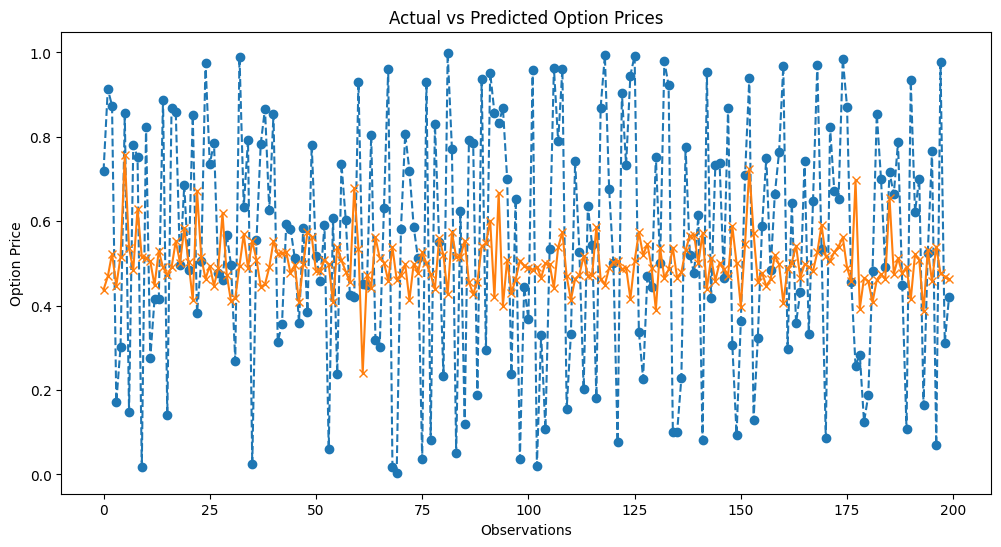

In [5]:
# Generating synthetic data for option pricing (e.g., Black-Scholes model outputs)
X = np.random.rand(1000, 3)  # Features: [Underlying Price, Volatility, Time to Maturity]
y = np.random.rand(1000, 1)  # Option Prices

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Building the Neural Network model
model = Sequential()

# Add an Input layer as the first layer
model.add(Input(shape=(3,)))

# Add subsequent layers
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='linear'))

# Compiling the model
model.compile(optimizer='adam', loss='mse')

# Training the model
model.fit(X_train, y_train, epochs=100, batch_size=10, validation_split=0.2)

# Predicting option prices
predictions = model.predict(X_test)

# Plotting the actual vs predicted option prices
plt.figure(figsize=(12, 6))

# Plot the actual option prices
plt.plot(y_test, label="Actual Option Price", linestyle='--', marker='o')

# Plot the predicted option prices
plt.plot(predictions, label="Predicted Option Price", linestyle='-', marker='x')

# Adding title and labels
plt.title("Actual vs Predicted Option Prices")
plt.xlabel("Observations")
plt.ylabel("Option Price")


### Neural Networks for Time Series Forecasting in Options Pricing

Epoch 1/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.1186 - val_loss: 0.0931
Epoch 2/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0865 - val_loss: 0.0865
Epoch 3/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0849 - val_loss: 0.0884
Epoch 4/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0855 - val_loss: 0.0871
Epoch 5/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0849 - val_loss: 0.0847
Epoch 6/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0846 - val_loss: 0.0880
Epoch 7/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0852 - val_loss: 0.0849
Epoch 8/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0833 - val_loss: 0.0833
Epoch 9/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0831 - val_loss: 0.0836
Epoch 10/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0839 - val_loss: 0.0835
Epoch 11/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0838 - val_loss: 0.0839
Epoch 12/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0835 - val_l

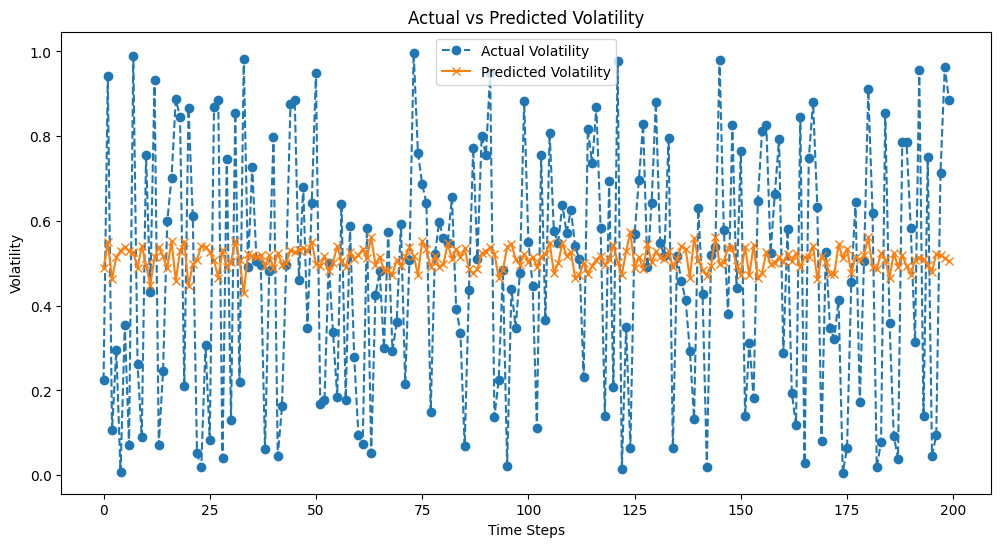

In [6]:
# Assuming X is the time series data for historical volatility
X = np.random.rand(1000, 10, 1)  # Shape: [Samples, Time Steps, Features]
y = np.random.rand(1000, 1)  # Future volatility

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Building the LSTM model
model = Sequential()

# Add an Input layer for LSTM
model.add(Input(shape=(10, 1)))

# Add LSTM and Dense layers
model.add(LSTM(50))
model.add(Dense(1))

# Compiling the model
model.compile(optimizer='adam', loss='mse')

# Training the model
model.fit(X_train, y_train, epochs=50, batch_size=20, validation_split=0.2)

# Predicting future volatility
predictions = model.predict(X_test)

# Plotting the actual vs predicted volatility
plt.figure(figsize=(12, 6))

# Plot the actual volatility values
plt.plot(y_test, label="Actual Volatility", linestyle='--', marker='o')

# Plot the predicted volatility values
plt.plot(predictions, label="Predicted Volatility", linestyle='-', marker='x')

# Adding title and labels
plt.title("Actual vs Predicted Volatility")
plt.xlabel("Time Steps")
plt.ylabel("Volatility")
plt.legend()
plt.show()